In [1]:
import pandas as pd
import json
from pathlib import Path

DATA_DIR = Path("../../datasets/data_parsed_pruned")

In [2]:
with open(DATA_DIR / "manifest.json") as f:
    manifest = json.load(f)

list(manifest.items())[:5]

[('2025-03-04_output.xlsx|||A1',
  {'inputs_path': '2025-03-04_output_xlsx__A1__inputs.parquet',
   'outputs_path': '2025-03-04_output_xlsx__A1__outputs.parquet'}),
 ('2025-03-04_output.xlsx|||A2',
  {'inputs_path': '2025-03-04_output_xlsx__A2__inputs.parquet',
   'outputs_path': '2025-03-04_output_xlsx__A2__outputs.parquet'}),
 ('2025-03-04_output.xlsx|||A3',
  {'inputs_path': '2025-03-04_output_xlsx__A3__inputs.parquet',
   'outputs_path': '2025-03-04_output_xlsx__A3__outputs.parquet'}),
 ('2025-03-04_output.xlsx|||A4',
  {'inputs_path': '2025-03-04_output_xlsx__A4__inputs.parquet',
   'outputs_path': '2025-03-04_output_xlsx__A4__outputs.parquet'}),
 ('2025-03-04_output.xlsx|||A5',
  {'inputs_path': '2025-03-04_output_xlsx__A5__inputs.parquet',
   'outputs_path': '2025-03-04_output_xlsx__A5__outputs.parquet'})]

In [3]:
key = list(manifest.keys())[0]
entry = manifest[key]
print(key)

inp = pd.read_parquet(DATA_DIR / entry["inputs_path"])
out = pd.read_parquet(DATA_DIR / entry["outputs_path"])

2025-03-04_output.xlsx|||A1


In [ ]:
print("inputs")
print(inp.shape)
print(inp.head(10))
print("outputs")
print(out.shape)
print(out.tail(10))

inputs
(1234, 14)
   Time_seconds    DNA      FB  K-Glut  Lysate 2%PEG  Maltose  Mg-Glut  \
0             0    0.0  2400.0     0.0           0.0      0.0      0.0   
1            60  289.0     0.0     0.0           0.0      0.0      0.0   
2           120    0.0     0.0     0.0           0.0      0.0      0.0   
3           180    0.0     0.0     0.0           0.0      0.0     48.0   
4           240    0.0     0.0     0.0           0.0      0.0      0.0   
5           300    0.0     0.0     0.0           0.0      0.0      0.0   
6           360    0.0     0.0     0.0           0.0      0.0      0.0   
7           420    0.0     0.0     0.0           0.0      0.0      0.0   
8           480    0.0     0.0     0.0           0.0      0.0      0.0   
9           540    0.0     0.0     0.0           0.0      0.0      0.0   

   PEG8000  T7RNAP   water  3PGA   AA  NTPs     DNA c  
0     0.00     0.0  2110.0   0.0  0.0   0.0  0.000000  
1     0.00     0.0     0.0   0.0  0.0   0.0  4.938112  

In [5]:
print(out.shape)
out.tail(10)

(1234, 3)


,Time_seconds,Broccoli [RFU],mCherry [RFU]
1224,73440.0,1,893
1225,73500.0,1,893
1226,73560.0,1,893
1227,73620.0,1,895
1228,73680.0,1,895
1229,73740.0,1,895
1230,73800.0,1,895
1231,73860.0,1,895
1232,73920.0,2,895
1233,73980.0,2,895


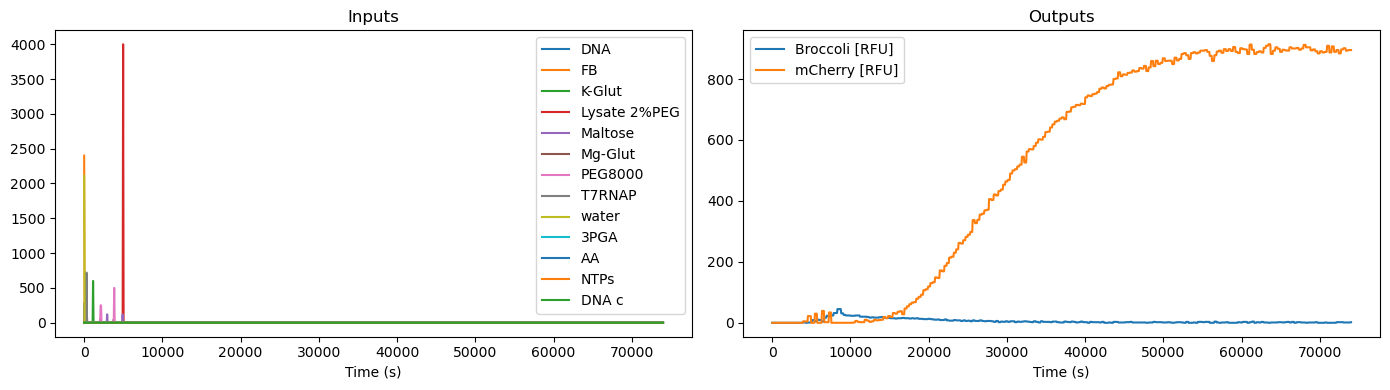

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for col in inp.columns:
    if col != "Time_seconds":
        axes[0].plot(inp["Time_seconds"], inp[col], label=col)
axes[0].set_title("Inputs")
axes[0].set_xlabel("Time (s)")
axes[0].legend()

for col in out.columns:
    if col != "Time_seconds":
        axes[1].plot(out["Time_seconds"], out[col], label=col)
axes[1].set_title("Outputs")
axes[1].set_xlabel("Time (s)")
axes[1].legend()

plt.tight_layout()
plt.show()

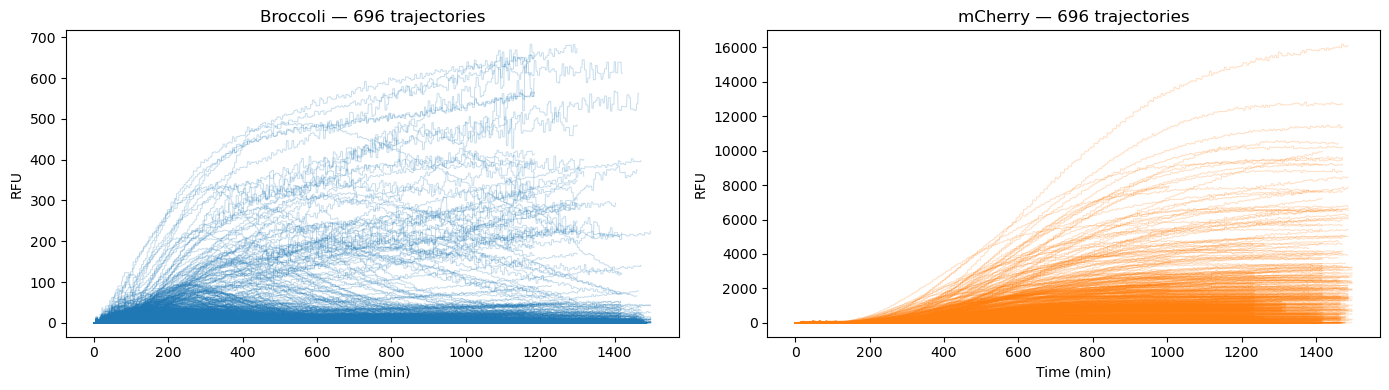

In [6]:
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = Path("../../datasets/data_parsed_pruned")
with open(DATA_DIR / "manifest.json") as f:
    manifest = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

n = 0
for key, entry in manifest.items():
    out = pd.read_parquet(DATA_DIR / entry["outputs_path"])
    t_min = out["Time_seconds"] / 60.0
    axes[0].plot(t_min, out["Broccoli [RFU]"], color="tab:blue",   alpha=0.25, lw=0.7)
    axes[1].plot(t_min, out["mCherry [RFU]"],  color="tab:orange", alpha=0.25, lw=0.7)
    n += 1

axes[0].set_title(f"Broccoli — {n} trajectories")
axes[0].set_xlabel("Time (min)"); axes[0].set_ylabel("RFU")
axes[1].set_title(f"mCherry — {n} trajectories")
axes[1].set_xlabel("Time (min)"); axes[1].set_ylabel("RFU")
plt.tight_layout()
plt.show()

In [17]:
lengths = {k: pd.read_parquet(DATA_DIR / v["outputs_path"]).shape[0] for k, v in manifest.items()}
pd.Series(lengths).describe()

count     696.000000
mean     1325.103448
std       136.428960
min      1005.000000
25%      1234.000000
50%      1319.000000
75%      1461.000000
max      1498.000000
dtype: float64

In [18]:
# ── Output statistics across all 696 experiments ──────────────────────────
import numpy as np

records = []
for key, entry in manifest.items():
    o = pd.read_parquet(DATA_DIR / entry["outputs_path"])
    records.append({
        "key":          key,
        "K":            len(o),
        "t_end_h":      o["Time_seconds"].max() / 3600,
        "broccoli_max": o["Broccoli [RFU]"].max(),
        "broccoli_fin": o["Broccoli [RFU]"].iloc[-1],
        "mcherry_max":  o["mCherry [RFU]"].max(),
        "mcherry_fin":  o["mCherry [RFU]"].iloc[-1],
    })

stats = pd.DataFrame(records)
print(f"N = {len(stats)} experiments\n")
print(stats[["K","t_end_h","broccoli_max","mcherry_max","mcherry_fin"]].describe().round(1))

N = 696 experiments

            K  t_end_h  broccoli_max  mcherry_max  mcherry_fin
count   696.0    696.0         696.0        696.0        696.0
mean   1325.1     22.1          59.3       1394.1       1355.5
std     136.4      2.3          99.4       1921.1       1909.5
min    1005.0     16.7           0.0          0.0          0.0
25%    1234.0     20.6          16.0        218.0        187.2
50%    1319.0     22.0          27.0        797.5        767.5
75%    1461.0     24.3          49.0       1679.2       1649.8
max    1498.0     25.0         683.0      16181.0      16116.0


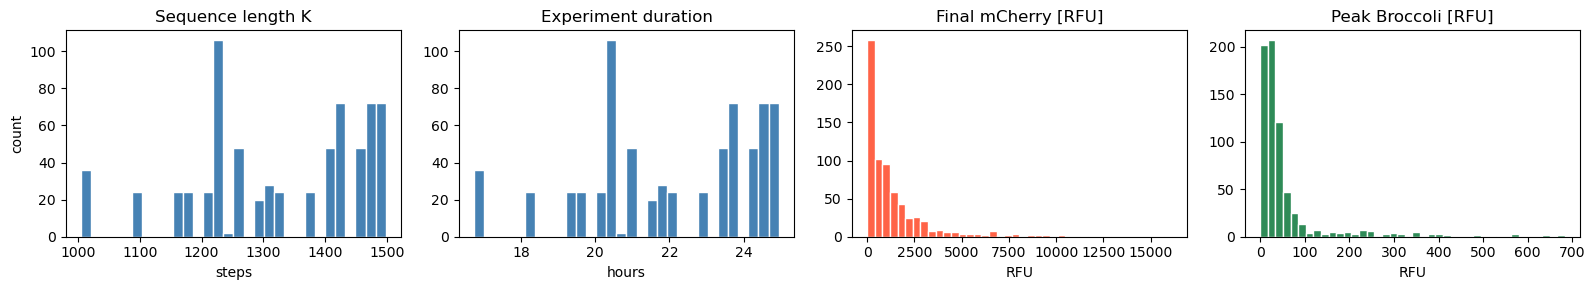

Low-yield experiments (final mCherry < 100): 134 / 696


In [19]:
# ── Distribution plots: yields and sequence lengths ───────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

axes[0].hist(stats["K"], bins=30, color="steelblue", edgecolor="white")
axes[0].set(title="Sequence length K", xlabel="steps", ylabel="count")

axes[1].hist(stats["t_end_h"], bins=30, color="steelblue", edgecolor="white")
axes[1].set(title="Experiment duration", xlabel="hours")

axes[2].hist(stats["mcherry_fin"], bins=40, color="tomato", edgecolor="white")
axes[2].set(title="Final mCherry [RFU]", xlabel="RFU")

axes[3].hist(stats["broccoli_max"], bins=40, color="seagreen", edgecolor="white")
axes[3].set(title="Peak Broccoli [RFU]", xlabel="RFU")

fig.tight_layout()
plt.show()

# Flag low-yield experiments
low_yield = stats[stats["mcherry_fin"] < 100]
print(f"Low-yield experiments (final mCherry < 100): {len(low_yield)} / {len(stats)}")

In [20]:
# ── Which input channels are actually used? ───────────────────────────────
# Count how many experiments have at least one nonzero pulse per channel
INPUT_COLS = [c for c in inp.columns if c != "Time_seconds"]

channel_usage = {col: 0 for col in INPUT_COLS}
channel_pulse_counts = {col: [] for col in INPUT_COLS}

for key, entry in manifest.items():
    i = pd.read_parquet(DATA_DIR / entry["inputs_path"])
    for col in INPUT_COLS:
        nonzero = (i[col] != 0).sum()
        if nonzero > 0:
            channel_usage[col] += 1
        channel_pulse_counts[col].append(int(nonzero))

usage_df = pd.DataFrame({
    "channel":        list(channel_usage.keys()),
    "n_experiments":  list(channel_usage.values()),
    "pct_used":       [v / len(manifest) * 100 for v in channel_usage.values()],
    "mean_pulses":    [np.mean(channel_pulse_counts[c]) for c in channel_usage],
}).sort_values("pct_used", ascending=False)

print(usage_df.to_string(index=False))

     channel  n_experiments   pct_used  mean_pulses
         DNA            696 100.000000     1.001437
          FB            696 100.000000     1.005747
Lysate 2%PEG            696 100.000000     1.666667
      T7RNAP            696 100.000000     1.005747
       water            696 100.000000     1.001437
       DNA c            696 100.000000    13.033046
     Mg-Glut            680  97.701149     1.673851
     PEG8000            617  88.649425     1.577586
     Maltose            597  85.775862     1.495690
      K-Glut            532  76.436782     1.362069
        3PGA            316  45.402299     1.307471
          AA            315  45.258621     1.227011
        NTPs            170  24.425287     0.683908


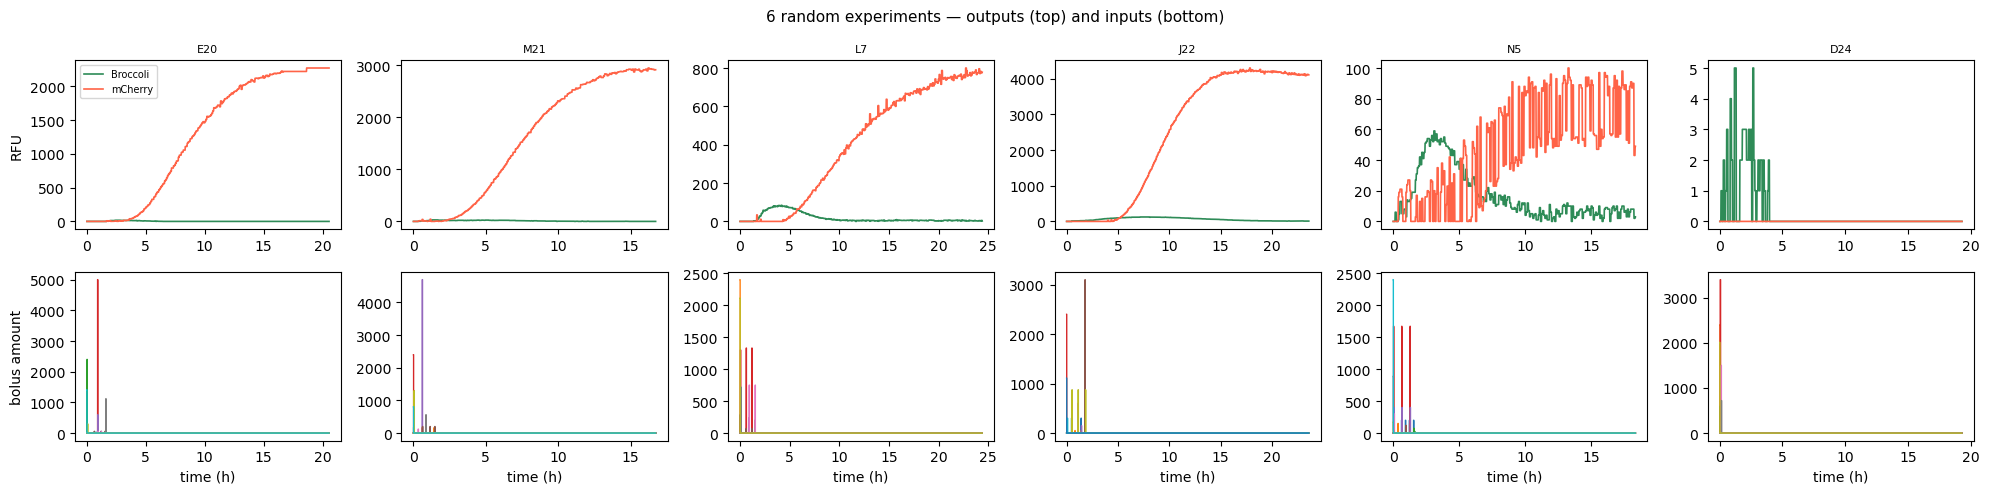

In [21]:
# ── Sample 6 random experiments to see the variety ────────────────────────
sample_keys = list(manifest.keys())
rng = np.random.default_rng(0)
chosen = rng.choice(len(sample_keys), size=6, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(20, 5))
for col_i, idx in enumerate(chosen):
    key   = sample_keys[idx]
    entry = manifest[key]
    i_df  = pd.read_parquet(DATA_DIR / entry["inputs_path"])
    o_df  = pd.read_parquet(DATA_DIR / entry["outputs_path"])
    t_h   = o_df["Time_seconds"] / 3600

    # top row: outputs
    ax = axes[0, col_i]
    ax.plot(t_h, o_df["Broccoli [RFU]"], color="seagreen",  label="Broccoli", lw=1.2)
    ax.plot(t_h, o_df["mCherry [RFU]"],  color="tomato",    label="mCherry",  lw=1.2)
    ax.set_title(key.split("|||")[-1], fontsize=8)
    if col_i == 0:
        ax.set_ylabel("RFU")
        ax.legend(fontsize=7)

    # bottom row: inputs (excluding DNA c)
    ax2 = axes[1, col_i]
    t_in = i_df["Time_seconds"] / 3600
    for col in i_df.columns:
        if col not in ("Time_seconds", "DNA c") and (i_df[col] != 0).any():
            ax2.step(t_in, i_df[col], where="mid", lw=1.0, label=col)
    if col_i == 0:
        ax2.set_ylabel("bolus amount")
    ax2.set_xlabel("time (h)")

fig.suptitle("6 random experiments — outputs (top) and inputs (bottom)", fontsize=11)
fig.tight_layout()
plt.show()

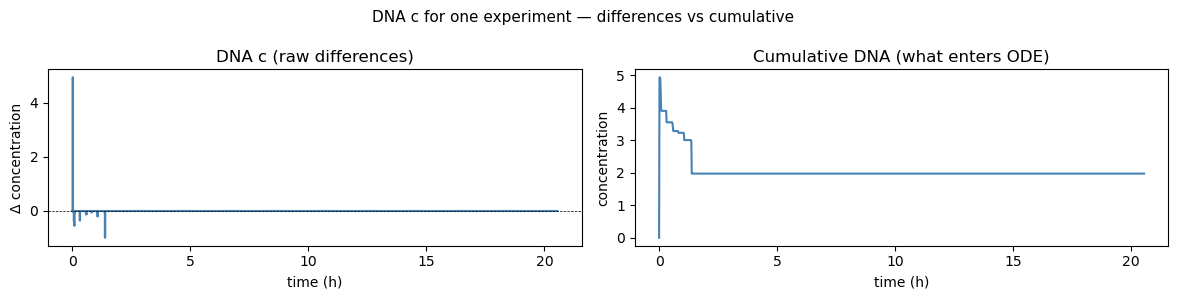

DNA c negatives: 13 / 1234 steps  (min=-0.987, likely noise)
Cumulative DNA final: 1.974


In [22]:
# ── DNA c: understand the column ──────────────────────────────────────────
# The parser computes diffs (row[t] - row[t-1]), so DNA c = change in cumulative DNA.
# Cumulative DNA is what enters the ODE mechanistically.
# Negative values = noise / dilution effects after the initial addition.
dna_c = inp["DNA c"]
dna_cum = dna_c.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].step(inp["Time_seconds"]/3600, dna_c, where="mid", color="steelblue")
axes[0].set(title="DNA c (raw differences)", xlabel="time (h)", ylabel="Δ concentration")
axes[0].axhline(0, color="k", lw=0.5, ls="--")

axes[1].plot(inp["Time_seconds"]/3600, dna_cum, color="steelblue")
axes[1].set(title="Cumulative DNA (what enters ODE)", xlabel="time (h)", ylabel="concentration")

fig.suptitle("DNA c for one experiment — differences vs cumulative", fontsize=11)
fig.tight_layout()
plt.show()

print(f"DNA c negatives: {(dna_c < 0).sum()} / {len(dna_c)} steps  "
      f"(min={dna_c.min():.3f}, likely noise)")
print(f"Cumulative DNA final: {dna_cum.iloc[-1]:.3f}")

Experiments with yield > 200: 519 / 696

Plateau step distribution:
count     519.0
mean     1124.0
std       234.0
min       499.0
25%       954.0
50%      1151.0
75%      1321.0
90%      1410.0
95%      1446.0
99%      1485.0
max      1496.0
Name: plateau_at, dtype: float64


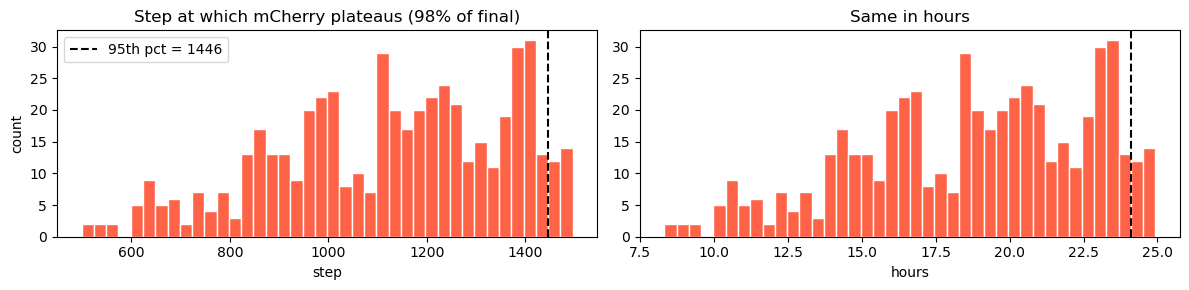


Recommended truncation: K=1446 (24.1h) covers 95% of experiments


In [24]:
# ── When does mCherry plateau? Find the right truncation point ────────────
MIN_YIELD = 200  # ignore failed/near-zero experiments for this analysis

plateau_steps = []  # step at which each experiment plateaus (within 2% of final value)

for key, entry in manifest.items():
    o   = pd.read_parquet(DATA_DIR / entry["outputs_path"])
    mch = o["mCherry [RFU]"].to_numpy()
    final = mch[-1]
    if final < MIN_YIELD:
        continue  # skip failed experiments

    # find first step where mCherry is within 2% of final value and stays there
    threshold = 0.98 * final
    plateau_at = len(mch)  # default: never reaches plateau
    for k in range(len(mch) - 1, -1, -1):
        if mch[k] < threshold:
            plateau_at = k + 1
            break
    plateau_steps.append({"key": key, "K": len(mch),
                           "plateau_at": plateau_at, "final_mcherry": final})

df_p = pd.DataFrame(plateau_steps)
print(f"Experiments with yield > {MIN_YIELD}: {len(df_p)} / {len(manifest)}")
print(f"\nPlateau step distribution:")
print(df_p["plateau_at"].describe(percentiles=[.25,.5,.75,.9,.95,.99]).round(0))

# Plot distribution of plateau steps
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(df_p["plateau_at"], bins=40, color="tomato", edgecolor="white")
axes[0].axvline(df_p["plateau_at"].quantile(0.95), color="k", ls="--",
                label=f"95th pct = {df_p['plateau_at'].quantile(0.95):.0f}")
axes[0].set(title="Step at which mCherry plateaus (98% of final)",
            xlabel="step", ylabel="count")
axes[0].legend()

axes[1].hist(df_p["plateau_at"] * 60 / 3600, bins=40, color="tomato", edgecolor="white")
axes[1].axvline(df_p["plateau_at"].quantile(0.95) * 60 / 3600, color="k", ls="--")
axes[1].set(title="Same in hours", xlabel="hours")
fig.tight_layout()
plt.show()

K95 = int(df_p["plateau_at"].quantile(0.95))
print(f"\nRecommended truncation: K={K95} ({K95*60/3600:.1f}h) covers 95% of experiments")

In [25]:
# ── How many experiments survive different truncation strategies? ──────────
MIN_YIELD  = 200
K_TRUNC    = 1446  # 95th percentile plateau step

survive = {"key": [], "K": [], "final_mcherry": [], "kept": [], "drop_reason": []}

for key, entry in manifest.items():
    o     = pd.read_parquet(DATA_DIR / entry["outputs_path"])
    K     = len(o)
    final = o["mCherry [RFU]"].iloc[-1]

    if final < MIN_YIELD:
        reason = "low_yield"
        kept   = False
    elif K < K_TRUNC:
        reason = "too_short"
        kept   = False
    else:
        reason = ""
        kept   = True

    survive["key"].append(key)
    survive["K"].append(K)
    survive["final_mcherry"].append(final)
    survive["kept"].append(kept)
    survive["drop_reason"].append(reason)

df_s = pd.DataFrame(survive)
print(f"Total experiments:  {len(df_s)}")
print(f"Kept (K≥{K_TRUNC} and yield≥{MIN_YIELD}):  {df_s['kept'].sum()}")
print(f"Dropped — too short:  {(df_s['drop_reason']=='too_short').sum()}")
print(f"Dropped — low yield:  {(df_s['drop_reason']=='low_yield').sum()}")

# Are short experiments also low-yield, or are they a separate group?
short = df_s[df_s["drop_reason"] == "too_short"]
kept  = df_s[df_s["kept"]]
print(f"\nShort experiments — mCherry distribution:")
print(short["final_mcherry"].describe(percentiles=[.25,.5,.75]).round(1))
print(f"\nKept experiments — mCherry distribution:")
print(kept["final_mcherry"].describe(percentiles=[.25,.5,.75]).round(1))

# Are short experiments from specific date batches?
df_s["date"] = df_s["key"].str.extract(r"(\d{4}-\d{2}-\d{2})")
short_dates  = df_s[df_s["drop_reason"] == "too_short"]["date"].value_counts()
print(f"\nShort experiments by date batch (top 5):")
print(short_dates.head())

Total experiments:  696
Kept (K≥1446 and yield≥200):  159
Dropped — too short:  360
Dropped — low yield:  177

Short experiments — mCherry distribution:
count     360.0
mean     1459.1
std      1475.1
min       201.0
25%       560.0
50%       992.5
75%      1761.2
max      9959.0
Name: final_mcherry, dtype: float64

Kept experiments — mCherry distribution:
count      159.0
mean      2572.4
std       2769.7
min        208.0
25%        772.0
50%       1528.0
75%       3070.5
max      16116.0
Name: final_mcherry, dtype: float64

Short experiments by date batch (top 5):
date
2025-05-11    45
2025-03-04    24
2025-03-10    24
2025-05-01    24
2025-05-10    24
Name: count, dtype: int64
